# **Pertemuan 3: Aplikasi Interaktif: Kode QR, Landmark, dan Image Overlay**

**Tujuan Sesi:**  
Peserta mengintegrasikan semua pengetahuan untuk membangun aplikasi interaktif. Konsep overlay akan diperkenalkan secara *"just-in-time"* sebagai bagian dari proyek akhir.


## **Identitas Mahasiswa**

- **Nama:** Cidesta Mentari Marintan Simbolon  
- **NIM:** 122400096  
- **Kelas:** Pengolahan Citra

## **Membuat Pembaca QR Code**

Sekarang, kita akan memanfaatkan library `pyzbar` dan `cv2.QRCodeDetector` untuk menemukan dan membaca QR Code

In [6]:
# Import library yang digunakan
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

# Menampilkan versi library
print("Numpy Version :", np.__version__)
print("Matplotlib Version :", plt.matplotlib.__version__)
print("OpenCV Version :", cv2.__version__)

Numpy Version : 2.4.6
Matplotlib Version : 3.10.9
OpenCV Version : 4.13.0


>>Kode di atas digunakan untuk mengimpor beberapa library dasar yang diperlukan dalam pengolahan citra digital, seperti NumPy untuk operasi numerik, Matplotlib untuk visualisasi gambar, OpenCV untuk pemrosesan citra, dan OS untuk pengelolaan file. Program kemudian menampilkan versi library yang digunakan sebagai langkah pengecekan awal agar seluruh modul dapat berjalan dengan baik sebelum proses pengolahan citra dilakukan.

### **Memuat Gambar QR Code**

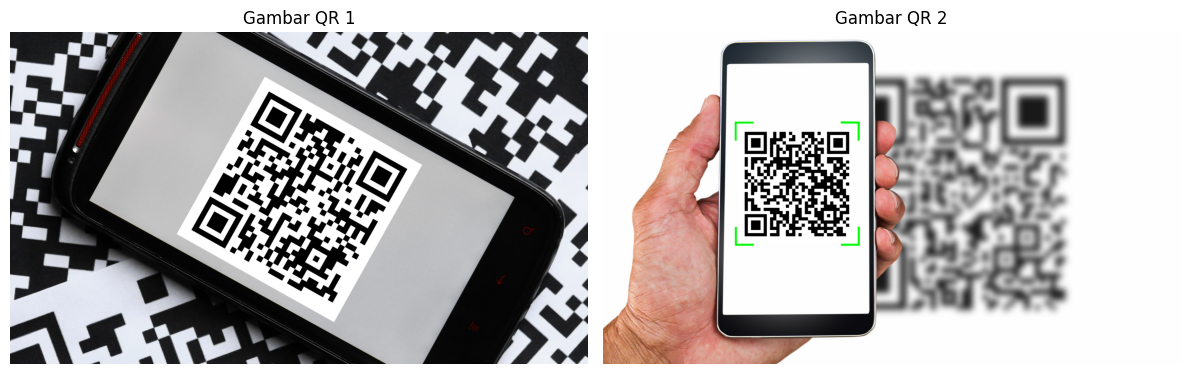

In [3]:
# Menentukan lokasi file gambar QR Code
import os
import cv2
import matplotlib.pyplot as plt

path_qr1 = os.path.join('data', 'qr1.png')
path_qr2 = os.path.join('data', 'qr2.png')

# Membaca gambar menggunakan OpenCV
qr_img1 = cv2.imread(path_qr1)
qr_img2 = cv2.imread(path_qr2)

# Menampilkan gambar QR Code
figure, tampil = plt.subplots(1, 2, figsize=(12, 5))

tampil[0].imshow(cv2.cvtColor(qr_img1, cv2.COLOR_BGR2RGB))
tampil[0].set_title('Gambar QR 1')
tampil[0].axis('off')

tampil[1].imshow(cv2.cvtColor(qr_img2, cv2.COLOR_BGR2RGB))
tampil[1].set_title('Gambar QR 2')
tampil[1].axis('off')

plt.tight_layout()
plt.show()

>>Kode di atas digunakan untuk membaca dua gambar QR Code dari folder data menggunakan OpenCV, kemudian menampilkannya berdampingan dengan bantuan Matplotlib. Fungsi `cv2.cvtColor()`digunakan untuk mengubah format warna BGR menjadi RGB agar warna gambar tampil dengan benar saat divisualisasikan.

### **Membaca QR Code**

In [4]:
# Membaca isi QR Code menggunakan pyzbar
hasil_qr1 = decode(qr_img1)

# Menampilkan hasil deteksi QR Code
print("Hasil pembacaan QR Code:")
print(hasil_qr1)

Hasil pembacaan QR Code:
[Decoded(data=b'https://mctm.web.id/course/', type='QRCODE', rect=Rect(left=589, top=192, width=705, height=705), polygon=[Point(x=589, y=644), Point(x=1041, y=897), Point(x=1294, y=445), Point(x=841, y=192)], quality=1, orientation='UP')]


>>Kode di atas digunakan untuk mendeteksi dan membaca isi QR Code dari gambar menggunakan fungsi `decode()` pada library Pyzbar. Hasil pembacaan kemudian disimpan ke dalam variabel dan ditampilkan pada layar untuk mengetahui informasi atau data yang tersimpan di dalam QR Code tersebut.

In [5]:
# Membuat objek pendeteksi QR Code dari OpenCV
detektor_qr = cv2.QRCodeDetector()

# Mendeteksi dan membaca isi QR Code
data_qr, titik_qr, _ = detektor_qr.detectAndDecode(qr_img1)

# Menampilkan hasil deteksi
print("Isi QR Code :", data_qr)
print("Koordinat QR Code :", titik_qr)

Isi QR Code : 
Koordinat QR Code : [[[ 841.78784  192.59317]
  [1292.1832   445.0876 ]
  [1040.       897.     ]
  [ 589.45557  643.1865 ]]]


>>Kode di atas digunakan untuk mendeteksi sekaligus membaca isi QR Code menggunakan fitur `QRCodeDetector()` dari OpenCV. Program akan mengambil data yang tersimpan di dalam QR Code serta koordinat posisi QR Code pada gambar, kemudian menampilkannya sebagai hasil proses deteksi.

### **Deteksi QR Code**

Data QR : https://www.youtube.com/watch?v=FbR9Xr0TVdY


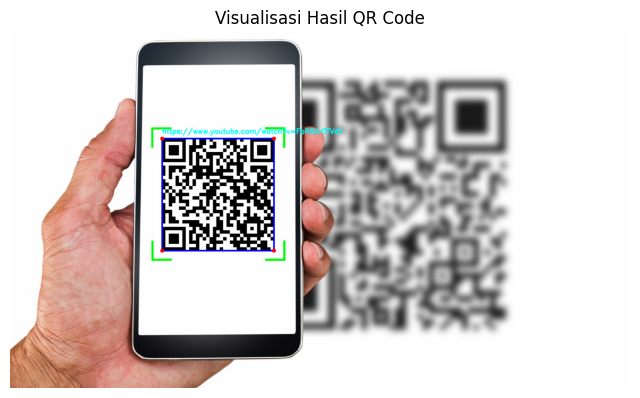

In [8]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pyzbar.pyzbar import decode

# Menyalin gambar asli
hasil_gambar = qr_img2.copy()

# Membaca QR Code
deteksi_qr = decode(hasil_gambar)

# Proses deteksi QR
for data in deteksi_qr:

    # Mengambil koordinat QR Code
    area = data.polygon

    if len(area) == 4:
        titik_qr = np.array([[p.x, p.y] for p in area], np.int32)

        # Membuat kotak warna biru
        cv2.polylines(hasil_gambar, [titik_qr], True, (255, 0, 0), 4)

        # Memberi titik di setiap sudut
        for titik in titik_qr:
            cv2.circle(hasil_gambar, tuple(titik), 6, (0, 0, 255), -1)

    # Mengambil isi QR
    teks_qr = data.data.decode('utf-8')
    print("Data QR :", teks_qr)

    # Posisi teks
    x, y = data.rect.left, data.rect.top

    # Menampilkan teks pada gambar
    cv2.putText(hasil_gambar, teks_qr,
                (x, y - 15),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (255, 255, 0),
                2)

# Menampilkan hasil akhir
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(hasil_gambar, cv2.COLOR_BGR2RGB))
plt.title("Visualisasi Hasil QR Code")
plt.axis('off')
plt.show()

>>Kode di atas digunakan untuk mendeteksi QR Code menggunakan Pyzbar, kemudian menampilkan area QR Code dengan garis dan titik penanda pada setiap sudutnya. Selain itu, isi QR Code juga ditampilkan pada gambar sehingga hasil visualisasi deteksi menjadi lebih jelas dan informatif.

In [2]:
import cv2
import numpy as np
from pyzbar.pyzbar import decode

# Mengaktifkan kamera laptop
kamera = cv2.VideoCapture(0)

# Mengecek apakah kamera berhasil dibuka
if not kamera.isOpened():
    print("Kamera gagal dijalankan")
else:
    print("Tekan tombol Q untuk menutup kamera")

while True:

    # Membaca frame dari kamera
    berhasil, gambar = kamera.read()

    if not berhasil:
        print("Frame tidak terbaca")
        break

    # Deteksi QR Code
    hasil_qr = decode(gambar)

    for item in hasil_qr:

        # Mengambil koordinat QR Code
        koordinat = item.polygon

        if len(koordinat) == 4:
            titik = np.array([[p.x, p.y] for p in koordinat], np.int32)

            # Membuat garis kotak QR Code
            cv2.polylines(gambar, [titik], True, (255, 0, 0), 3)

            # Menambahkan titik sudut
            for p in titik:
                cv2.circle(gambar, tuple(p), 5, (0, 255, 255), -1)

        # Mengambil isi QR
        isi_data = item.data.decode('utf-8')
        print("QR Terdeteksi :", isi_data)

        # Posisi teks
        x, y = item.rect.left, item.rect.top

        # Menampilkan teks pada kamera
        cv2.putText(gambar,
                    isi_data,
                    (x, y - 15),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.8,
                    (0, 255, 0),
                    2)

    # Menampilkan hasil kamera
    cv2.imshow("Realtime QR Scanner", gambar)

    # Tombol keluar
    tombol = cv2.waitKey(1)

    if tombol == ord('q'):
        break

# Menutup kamera
kamera.release()
cv2.destroyAllWindows()

Tekan tombol Q untuk menutup kamera


>>Program yang saya buat digunakan untuk mendeteksi dan membaca QR Code secara real-time melalui kamera laptop menggunakan OpenCV dan Pyzbar. Pada hasil pengujian, kamera berhasil menampilkan objek QR Code yang terdeteksi dengan tambahan garis penanda serta titik pada setiap sudut QR Code. Data yang tersimpan di dalam QR Code juga dapat terbaca dan muncul langsung pada tampilan kamera maupun terminal. Dari hasil tersebut dapat diketahui bahwa program mampu melakukan proses deteksi dan decoding QR Code secara otomatis dengan cukup baik dan responsif.

> **Pertanyaan:** Bagaimana jika untuk mendeteksi Barcode?

> **Jawaban:** Jika digunakan untuk mendeteksi barcode, program dapat dilakukan dengan cara yang hampir sama karena library Pyzbar juga mendukung pembacaan berbagai jenis barcode selain QR Code. Perbedaannya terletak pada bentuk objek yang dideteksi, di mana barcode biasanya berbentuk garis-garis vertikal. Pada hasil deteksi, sistem tetap dapat membaca data yang tersimpan di dalam barcode dan menampilkannya pada layar secara otomatis menggunakan kamera maupun gambar input.

Barcode berhasil dibaca
Tipe Barcode : EAN13
Isi Barcode : 9786347013767


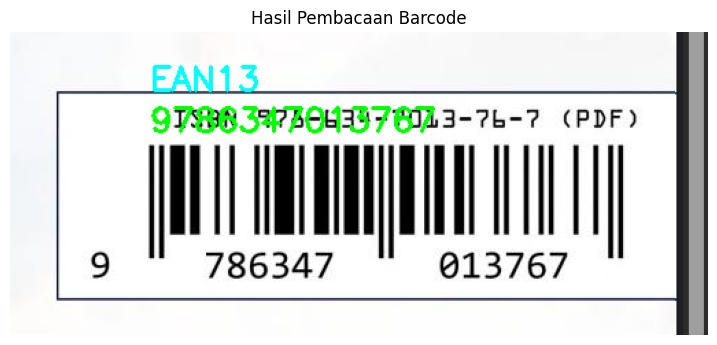

In [12]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pyzbar.pyzbar import decode

# Menentukan lokasi gambar barcode
lokasi_gambar = os.path.join("data", "barcode.png")

# Mengecek apakah file tersedia
if os.path.isfile(lokasi_gambar):

    # Membaca gambar barcode
    barcode_img = cv2.imread(lokasi_gambar)

    # Mengecek gambar berhasil dibaca
    if barcode_img is not None:

        # Proses scanning barcode
        hasil_scan = decode(barcode_img)

        # Jika barcode berhasil terdeteksi
        if hasil_scan:

            for item in hasil_scan:

                # Mengambil titik koordinat barcode
                posisi = item.polygon

                if len(posisi) == 4:

                    koordinat = np.array(
                        [[t.x, t.y] for t in posisi],
                        np.int32
                    )

                    # Membuat garis kotak barcode
                    cv2.polylines(
                        barcode_img,
                        [koordinat],
                        True,
                        (0, 0, 255),
                        6
                    )

                    # Menambahkan titik sudut barcode
                    for titik in koordinat:
                        cv2.circle(
                            barcode_img,
                            tuple(titik),
                            7,
                            (255, 255, 0),
                            -1
                        )

                # Mengambil isi dan tipe barcode
                isi_barcode = item.data.decode('utf-8')
                tipe_barcode = item.type

                print("Barcode berhasil dibaca")
                print("Tipe Barcode :", tipe_barcode)
                print("Isi Barcode :", isi_barcode)

                # Posisi teks
                x, y = item.rect.left, item.rect.top

                # Menampilkan teks pada gambar
                cv2.putText(
                    barcode_img,
                    tipe_barcode,
                    (x, y - 40),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.8,
                    (255, 255, 0),
                    2
                )

                cv2.putText(
                    barcode_img,
                    isi_barcode,
                    (x, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.8,
                    (0, 255, 0),
                    2
                )

        else:
            print("Barcode tidak terdeteksi")

    else:
        print("Gambar gagal dibuka")

else:
    print("File barcode tidak ditemukan")

# Mengubah warna BGR menjadi RGB
hasil_rgb = cv2.cvtColor(barcode_img, cv2.COLOR_BGR2RGB)

# Menampilkan hasil deteksi barcode
plt.figure(figsize=(9,6))
plt.imshow(hasil_rgb)
plt.title("Hasil Pembacaan Barcode")
plt.axis("off")
plt.show()

>>Pada program yang saya buat, sistem berhasil melakukan proses deteksi dan pembacaan barcode dari gambar input menggunakan OpenCV dan Pyzbar. Barcode yang terdeteksi akan diberi garis penanda berwarna merah dan titik pada setiap sudut area barcode agar posisi barcode terlihat lebih jelas. Selain itu, program juga menampilkan tipe barcode dan isi data yang berhasil dibaca baik pada terminal maupun langsung pada gambar hasil deteksi.

### **Membaca Landmark Wajah Menggunakan MediaPipe**

In [3]:
import mediapipe as mp

# Inisialisasi komponen MediaPipe
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles
mp_face_mesh = mp.solutions.face_mesh

# Setup FaceMesh
face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=False,
    max_num_faces=1,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

# Setup kamera
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Error: Kamera tidak bisa dibuka")
    exit()

print("Tekan 'q' untuk keluar")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Konversi warna ke RGB
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = face_mesh.process(rgb)
    h, w, _ = frame.shape

    if results.multi_face_landmarks:
        for face_landmarks in results.multi_face_landmarks:
            # Gambar koneksi antar titik (face mesh)
            mp_drawing.draw_landmarks(
                image=frame,
                landmark_list=face_landmarks,
                connections=mp_face_mesh.FACEMESH_TESSELATION,
                landmark_drawing_spec=None,
                connection_drawing_spec=mp_drawing.DrawingSpec(
                    color=(0, 255, 0), thickness=1, circle_radius=1)
            )

            # Tambahkan nomor ID di setiap landmark
            for idx, lm in enumerate(face_landmarks.landmark):
                x, y = int(lm.x * w), int(lm.y * h)
                cv2.putText(frame, str(idx), (x, y),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.25, (255, 0, 0), 1, cv2.LINE_AA)

    cv2.imshow("Face Mesh dengan Nomor ID", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


Tekan 'q' untuk keluar


### **Membaca Landmark Wajah Menggunakan dlib**

In [5]:
import os
import urllib.request
import bz2

# 1. Path model landmark Dlib
model_name = "shape_predictor_68_face_landmarks.dat"
predictor_path = os.path.join(os.getcwd(), model_name)

# File terkompresi (.bz2)
compressed_path = predictor_path + ".bz2"

# URL resmi model Dlib
predictor_url = "https://github.com/davisking/dlib-models/raw/master/shape_predictor_68_face_landmarks.dat.bz2"

# 2. Cek apakah model sudah ada
if os.path.exists(predictor_path):
    print("Model landmark sudah tersedia.")
else:
    print("Model belum ada. Mengunduh...")

    # Download file .bz2
    urllib.request.urlretrieve(predictor_url, compressed_path)
    print("Download selesai.")

    # Ekstrak file bz2
    print("Mengekstrak model...")
    with bz2.open(compressed_path, "rb") as f_in, open(predictor_path, "wb") as f_out:
        f_out.write(f_in.read())

    # Hapus file kompresi
    os.remove(compressed_path)

    print("Model berhasil disiapkan.")

Model landmark sudah tersedia.


>>Kode tersebut berfungsi untuk memastikan model landmark wajah Dlib `(shape_predictor_68_face_landmarks.dat)` tersedia di komputer. Pertama, program mengecek apakah file model sudah ada di direktori kerja. Jika belum ada, program akan mengunduh file terkompresi .`bz2` dari GitHub menggunakan urllib.request, lalu mengekstraknya dengan modul `bz2` menjadi file .dat yang bisa dipakai oleh Dlib. Setelah proses ekstraksi selesai, file .`bz2` dihapus agar tidak menumpuk file sementara. Jika file model sudah ada sebelumnya, program langsung melewati proses download dan menampilkan pesan bahwa model sudah tersedia, sehingga lebih efisien dan tidak mengunduh ulang.

In [7]:
import dlib
print(dlib.__version__)

20.0.1


In [8]:
import cv2
import dlib
import numpy as np

print("Semua library berhasil di-import")

Semua library berhasil di-import


In [7]:
import cv2
import dlib
import numpy as np

# detector & predictor
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")

cap = cv2.VideoCapture(0)

# index mata
LEFT_EYE = [36, 37, 38, 39, 40, 41]
RIGHT_EYE = [42, 43, 44, 45, 46, 47]

def eye_aspect_ratio(eye):
    A = np.linalg.norm(eye[1] - eye[5])
    B = np.linalg.norm(eye[2] - eye[4])
    C = np.linalg.norm(eye[0] - eye[3])
    ear = (A + B) / (2.0 * C)
    return ear

BLINK_THRESHOLD = 0.22

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = detector(gray)

    for face in faces:
        shape = predictor(gray, face)
        landmarks = np.array([[p.x, p.y] for p in shape.parts()])

        left_eye = landmarks[LEFT_EYE]
        right_eye = landmarks[RIGHT_EYE]

        left_ear = eye_aspect_ratio(left_eye)
        right_ear = eye_aspect_ratio(right_eye)

        ear = (left_ear + right_ear) / 2.0

        # status mata
        if ear < BLINK_THRESHOLD:
            status = "BLINK 😑"
            color = (0, 0, 255)
        else:
            status = "OPEN 🙂"
            color = (0, 255, 0)

        # gambar titik mata
        for (x, y) in left_eye:
            cv2.circle(frame, (x, y), 2, color, -1)
        for (x, y) in right_eye:
            cv2.circle(frame, (x, y), 2, color, -1)

        cv2.putText(frame, f"EAR: {ear:.2f}", (20, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

        cv2.putText(frame, status, (20, 80),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

    cv2.imshow("Blink Detection Pro 😎", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

>>Program ini menggunakan Dlib untuk mendeteksi wajah dan 68 titik landmark, kemudian mengambil titik-titik khusus mata kiri dan kanan untuk menghitung Eye Aspect Ratio (EAR), yaitu perbandingan jarak antar titik mata untuk menentukan apakah mata sedang terbuka atau berkedip. Jika nilai EAR turun di bawah ambang tertentu, sistem menganggap mata sedang berkedip dan menampilkan status “BLINK”, sedangkan jika di atas ambang maka dianggap “OPEN”. Hasilnya ditampilkan secara real-time dari kamera dengan visual titik mata dan teks status di layar OpenCV.

In [11]:
import cv2
import dlib
import numpy as np
import time

detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")

cap = cv2.VideoCapture(0)

LEFT_EYE = [36, 37, 38, 39, 40, 41]
RIGHT_EYE = [42, 43, 44, 45, 46, 47]

def eye_aspect_ratio(eye):
    A = np.linalg.norm(eye[1] - eye[5])
    B = np.linalg.norm(eye[2] - eye[4])
    C = np.linalg.norm(eye[0] - eye[3])
    return (A + B) / (2.0 * C)

BLINK_THRESHOLD = 0.22

blink_count = 0
blink_detected = False

prev_time = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = detector(gray)

    for face in faces:
        shape = predictor(gray, face)
        landmarks = np.array([[p.x, p.y] for p in shape.parts()])

        left_eye = landmarks[LEFT_EYE]
        right_eye = landmarks[RIGHT_EYE]

        ear = (eye_aspect_ratio(left_eye) + eye_aspect_ratio(right_eye)) / 2.0

        # LOGIC BLINK
        if ear < BLINK_THRESHOLD:
            if not blink_detected:
                blink_count += 1
                blink_detected = True
        else:
            blink_detected = False

        # gambar mata
        for (x, y) in left_eye:
            cv2.circle(frame, (x, y), 2, (0, 255, 255), -1)
        for (x, y) in right_eye:
            cv2.circle(frame, (x, y), 2, (0, 255, 255), -1)

        cv2.putText(frame, f"EAR: {ear:.2f}", (20, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

        cv2.putText(frame, f"Blinks: {blink_count}", (20, 80),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

    # FPS
    curr_time = time.time()
    fps = 1 / (curr_time - prev_time) if prev_time else 0
    prev_time = curr_time

    cv2.putText(frame, f"FPS: {int(fps)}", (20, 120),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)

    cv2.imshow("Blink Counter AI 😎", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

>>Program ini menggunakan Dlib untuk mendeteksi wajah dan landmark mata, kemudian menghitung Eye Aspect Ratio (EAR) untuk menentukan kondisi mata terbuka atau tertutup. Sistem menambahkan logika deteksi transisi sehingga setiap kedipan hanya dihitung sekali menggunakan variabel kontrol, lalu menampilkan jumlah blink secara real-time. Selain itu, program juga menampilkan FPS untuk menunjukkan performa sistem dan memberikan visualisasi titik mata menggunakan OpenCV sehingga hasilnya lebih interaktif dan cocok untuk aplikasi computer vision sederhana berbasis AI.

## **Image Overlay Ke Wajah**

In [9]:
import cv2
import dlib
import numpy as np
import os
import math

detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")

cap = cv2.VideoCapture(0)

glasses = cv2.imread("data/glasses.png", cv2.IMREAD_UNCHANGED)

def split_alpha(img):
    if img.shape[2] == 4:
        b, g, r, a = cv2.split(img)
        return cv2.merge((b, g, r)), a / 255.0
    return img, np.ones(img.shape[:2], dtype=float)

glasses_rgb, glasses_alpha = split_alpha(glasses)

def rotate_image(image, angle):
    h, w = image.shape[:2]
    center = (w // 2, h // 2)

    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_LINEAR,
                             borderMode=cv2.BORDER_TRANSPARENT)
    return rotated

def overlay(frame, overlay_img, alpha, x, y, w, h):
    if x < 0 or y < 0 or x+w > frame.shape[1] or y+h > frame.shape[0]:
        return frame

    overlay_resized = cv2.resize(overlay_img, (w, h))
    alpha_resized = cv2.resize(alpha, (w, h))[:, :, None]

    roi = frame[y:y+h, x:x+w]
    frame[y:y+h, x:x+w] = (alpha_resized * overlay_resized +
                           (1 - alpha_resized) * roi).astype(np.uint8)
    return frame

def get_eyes(landmarks):
    left = np.array([landmarks.part(36).x, landmarks.part(36).y])
    right = np.array([landmarks.part(45).x, landmarks.part(45).y])

    center = ((left + right) / 2).astype(int)
    dx = right[0] - left[0]
    dy = right[1] - left[1]

    angle = math.degrees(math.atan2(dy, dx))
    dist = np.linalg.norm(right - left)

    return center, dist, angle

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = detector(gray)

    for face in faces:
        landmarks = predictor(gray, face)

        center, dist, angle = get_eyes(landmarks)

        glasses_w = int(2.2 * dist)
        glasses_h = int(glasses_rgb.shape[0] * (glasses_w / glasses_rgb.shape[1]))

        # resize dulu
        resized = cv2.resize(glasses_rgb, (glasses_w, glasses_h))

        # rotate sesuai head tilt
        rotated = rotate_image(resized, angle)

        x = center[0] - glasses_w // 2
        y = center[1] - glasses_h // 2

        frame = overlay(frame, rotated, glasses_alpha, x, y, glasses_w, glasses_h)

        cv2.putText(frame, f"Angle: {int(angle)}", (20, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,255), 2)

    cv2.imshow("Head Tilt Glasses 😎", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

>>Program ini merupakan pengembangan filter kacamata real-time yang menggunakan Dlib untuk mendeteksi landmark wajah, kemudian menghitung posisi dan jarak antara kedua mata untuk menentukan ukuran kacamata. Berbeda dengan versi sebelumnya, program ini juga menghitung sudut kemiringan kepala berdasarkan posisi mata kiri dan kanan menggunakan fungsi trigonometri `atan2`, sehingga diperoleh nilai rotasi wajah. Gambar kacamata kemudian di-rotate sesuai sudut tersebut sebelum di-overlay ke wajah menggunakan alpha blending, menghasilkan efek filter yang mengikuti pergerakan dan kemiringan kepala secara lebih realistis dan natural.

In [11]:
import cv2
import dlib
import numpy as np
import os

# model
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")

cap = cv2.VideoCapture(0)

# load assets
glasses = cv2.imread("data/glasses.png", cv2.IMREAD_UNCHANGED)
lipstick = cv2.imread("data/lipstick.png", cv2.IMREAD_UNCHANGED)

# alpha split helper
def split_alpha(img):
    if img.shape[2] == 4:
        b, g, r, a = cv2.split(img)
        return cv2.merge((b, g, r)), a / 255.0
    else:
        return img, np.ones(img.shape[:2], dtype=float)

glasses_rgb, glasses_a = split_alpha(glasses)
lipstick_rgb, lipstick_a = split_alpha(lipstick)

filter_mode = 1  # default kacamata

# ===== FUNCTIONS =====
def overlay(frame, overlay_img, alpha, x, y, w, h):
    if x < 0 or y < 0 or x+w > frame.shape[1] or y+h > frame.shape[0]:
        return frame

    overlay_resized = cv2.resize(overlay_img, (w, h))
    alpha_resized = cv2.resize(alpha, (w, h))[:, :, None]

    roi = frame[y:y+h, x:x+w]
    frame[y:y+h, x:x+w] = (alpha_resized * overlay_resized +
                           (1 - alpha_resized) * roi).astype(np.uint8)
    return frame

def get_eyes(landmarks):
    left = np.array([landmarks.part(36).x, landmarks.part(36).y])
    right = np.array([landmarks.part(45).x, landmarks.part(45).y])
    center = ((left + right) / 2).astype(int)
    dist = np.linalg.norm(right - left)
    return center, dist

def get_lips(landmarks):
    left = np.array([landmarks.part(48).x, landmarks.part(48).y])
    right = np.array([landmarks.part(54).x, landmarks.part(54).y])
    top = np.array([landmarks.part(51).x, landmarks.part(51).y])
    bottom = np.array([landmarks.part(57).x, landmarks.part(57).y])

    center = ((top + bottom) / 2).astype(int)
    w = int(np.linalg.norm(right - left) * 1.6)
    h = int(np.linalg.norm(top - bottom) * 2.8)
    return center, w, h

# ===== LOOP =====
while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = detector(gray)

    for face in faces:
        landmarks = predictor(gray, face)

        # ========= FILTER SWITCH =========
        if filter_mode == 1:
            # 👓 GLASSES
            center, dist = get_eyes(landmarks)
            w = int(2.2 * dist)
            h = int(glasses_rgb.shape[0] * (w / glasses_rgb.shape[1]))
            x = center[0] - w // 2
            y = center[1] - h // 2
            frame = overlay(frame, glasses_rgb, glasses_a, x, y, w, h)

        elif filter_mode == 2:
            # 💄 LIPSTICK
            center, w, h = get_lips(landmarks)
            x = center[0] - w // 2
            y = center[1] - h // 2
            frame = overlay(frame, lipstick_rgb, lipstick_a, x, y, w, h)

    # UI TEXT
    cv2.putText(frame, f"Filter Mode: {filter_mode}", (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 2)

    cv2.putText(frame, "Press 1=Glasses | 2=Lipstick | 3=None", (20, 80),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

    cv2.imshow("AI Filter Switch System 😎", frame)

    key = cv2.waitKey(1) & 0xFF

    if key == ord('q'):
        break
    elif key == ord('1'):
        filter_mode = 1
    elif key == ord('2'):
        filter_mode = 2
    elif key == ord('3'):
        filter_mode = 3

cap.release()
cv2.destroyAllWindows()

>>Program ini merupakan sistem filter wajah real-time berbasis Dlib dan OpenCV yang memungkinkan pengguna mengganti efek wajah menggunakan tombol keyboard. Pertama, program mendeteksi wajah dan landmark 68 titik menggunakan Dlib, lalu memuat dua filter gambar yaitu kacamata dan lipstick yang memiliki transparansi (alpha channel). Sistem menggunakan variabel filter_mode untuk menentukan filter yang aktif: tombol 1 untuk kacamata, 2 untuk lipstick, dan 3 untuk menonaktifkan filter. Berdasarkan mode yang dipilih, program akan menghitung posisi wajah seperti area mata atau bibir menggunakan landmark, kemudian menyesuaikan ukuran gambar filter agar sesuai dengan wajah pengguna. Gambar filter tersebut kemudian ditempelkan ke frame kamera menggunakan teknik alpha blending agar terlihat natural. Hasilnya ditampilkan secara real-time sehingga pengguna dapat mengganti filter secara interaktif seperti aplikasi filter kamera modern.